In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
penguins = pd.read_table("penguins.txt", sep = ",")

In [4]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


Text(0, 0.5, 'Body Mass (g)')

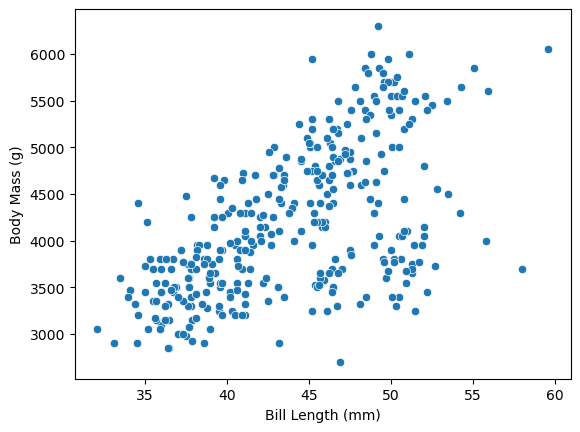

In [5]:
sns.scatterplot(data = penguins, x = "bill_length_mm", y = "body_mass_g")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Body Mass (g)")

To prepare for PCA, first standardize the data.

In [6]:
from sklearn.preprocessing import StandardScaler
penguin_feats = penguins[["bill_length_mm", "body_mass_g"]].dropna()
features_std = StandardScaler().fit_transform(penguin_feats)
features_std = pd.DataFrame(features_std, columns = penguin_feats.columns)

In [7]:
features_std

,bill_length_mm,body_mass_g
0,-0.884499,-0.564142
1,-0.811126,-0.501703
2,-0.664380,-1.188532
3,-1.324737,-0.938776
4,-0.847812,-0.689020
...,...,...
337,0.601305,0.903175
338,0.527932,0.809516
339,1.188289,1.933419
340,0.234440,1.246590


Perform Singular Value Decomposition (SVD), setting full_matrics to False so we just have the non-zero singular values and **p** left-singular vectors.

In [8]:
u, s, vt = np.linalg.svd(features_std, full_matrices = False)

Look at the eigenvectors

In [11]:
vt

array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]])

And the eigenvalues

In [12]:
s

array([23.35653142, 11.76743133])

The untransformed data: 

Text(0, 0.5, 'Body Mass (g)')

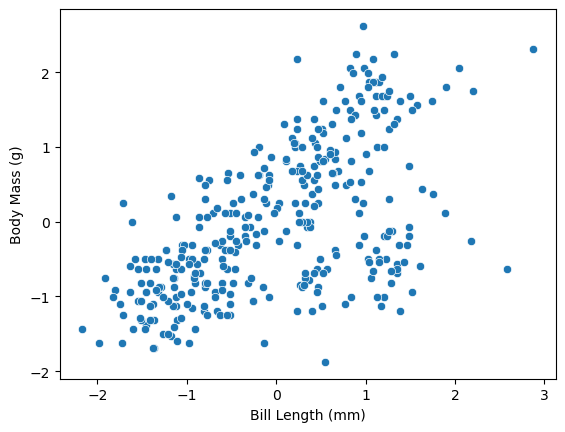

In [13]:
sns.scatterplot(data = features_std, x = "bill_length_mm", y = "body_mass_g")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Body Mass (g)")

Project the data to the first two principal components (the only two in this case):

In [15]:
new_penguins = features_std @ vt[[0,1]].T        # @ is the dot product 
new_penguins.head()

,0,1
0,-1.024344,0.226526
1,-0.928310,0.218795
2,-1.310207,-0.370632
3,-1.600545,0.272915
4,-1.086705,0.112283


And plot the PC1 and PC2 scores

Text(0, 0.5, 'Principal Component 2')

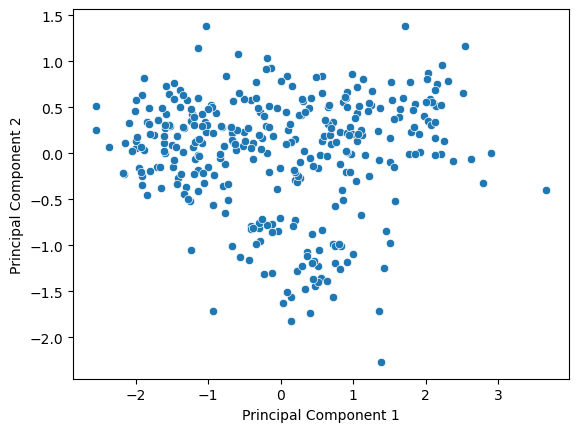

In [16]:
sns.scatterplot(x = new_penguins[0], y = new_penguins[1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

Now do the above process with 4 variables

In [17]:
penguin_feats = penguins[["bill_length_mm", "bill_depth_mm","flipper_length_mm", "body_mass_g"]].dropna()
features_std = StandardScaler().fit_transform(penguin_feats)
features_std = pd.DataFrame(features_std, columns = penguin_feats.columns)

In [18]:
features_std.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
3,-1.324737,1.089724,-0.563715,-0.938776
4,-0.847812,1.748985,-0.777373,-0.689020


In [19]:
u, s, vt = np.linalg.svd(features_std, full_matrices = False)

In [20]:
vt = pd.DataFrame(vt, columns = penguin_feats.columns, index = ["v1","v2","v3","v4"])
vt

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
v1,0.455250,-0.400335,0.576013,0.548350
v2,-0.597031,-0.797767,-0.002282,-0.084363
v3,-0.644301,0.418427,0.232084,0.596600
v4,0.145523,-0.167986,-0.783799,0.579882


The rows above represent the eigenvector associated with each PC. The columns represent the loadings of each variable on each PC.

Now use the eigenvectors to attain the scores for each PC. 

In [21]:
new_penguins = features_std @ vt.T

In [22]:
new_penguins.head()

,v1,v2,v3,v4
0,-1.843445,-0.047702,0.232794,0.523903
1,-1.306762,0.428348,0.029562,0.402426
2,-1.369181,0.154476,-0.198672,-0.528007
3,-1.878827,0.002048,0.618596,-0.478378
4,-1.911748,-0.829210,0.686584,-0.207428


Look at the eigenvalues, representing the amount of variance in the data captured by each PC

Text(0, 0.5, 'Var X Explained')

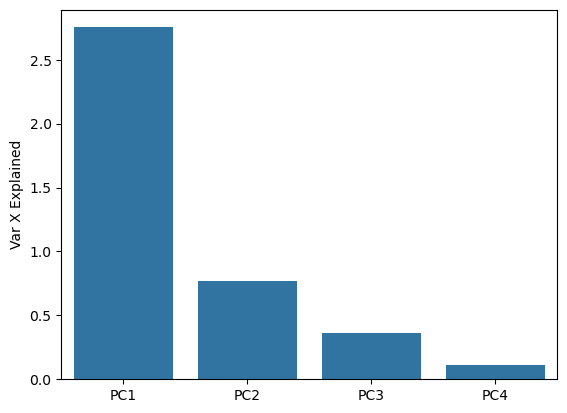

In [23]:
sns.barplot(x = ["PC1", "PC2", "PC3", "PC4"], y = s**2/len(features_std))
plt.ylabel("Var X Explained")

In [10]:
var_explained = s**2/len(features_std)
percent_var_explained = var_explained/np.sum(var_explained)

array([1.59510982, 0.40489018])

Text(0, 0.5, 'Var X Explained (%)')

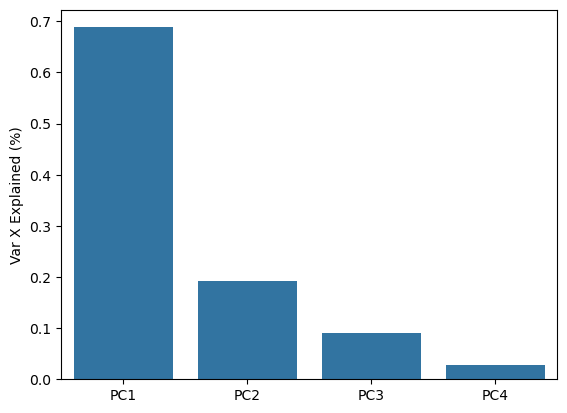

In [25]:
sns.barplot(x = ["PC1", "PC2", "PC3", "PC4"], y = percent_var_explained)
plt.ylabel("Var X Explained (%)")

Almost all variance is being explain by the first two PCs. This means that a plot of PC1 scores vs PC2 scores will be a very good representation of variation in the data.

Plot the loadings of each variable on PC1 and PC2. 

In [26]:
vt

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
v1,0.455250,-0.400335,0.576013,0.548350
v2,-0.597031,-0.797767,-0.002282,-0.084363
v3,-0.644301,0.418427,0.232084,0.596600
v4,0.145523,-0.167986,-0.783799,0.579882


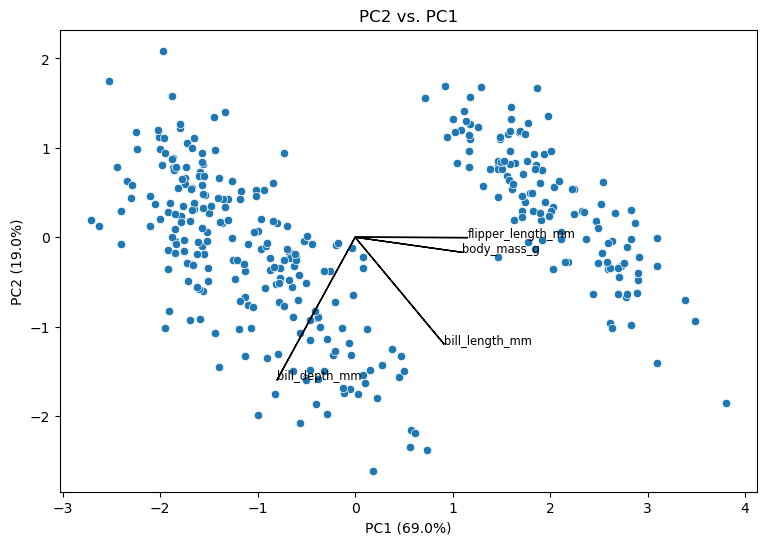

In [29]:
#offsets = np.random.uniform(0, 1, vt.shape[1])*.3
plt.figure(figsize = (9, 6))
plt.title("PC2 vs. PC1")
plt.xlabel(f"PC1 ({np.round(percent_var_explained[0],2)*100}%)")
plt.ylabel(f"PC2 ({np.round(percent_var_explained[1],2)*100}%)")
sns.scatterplot(x = new_penguins["v1"], y = new_penguins["v2"]);

for i in range(vt.shape[1]):
    plt.arrow(0, 0, vt.iloc[0,i]*2, vt.iloc[1,i]*2, color = "black")
    plt.text(vt.iloc[0,i]*2, vt.iloc[1,i]*2, features_std.columns[i], fontsize = "small")

See if the feature loadings are associated with species.

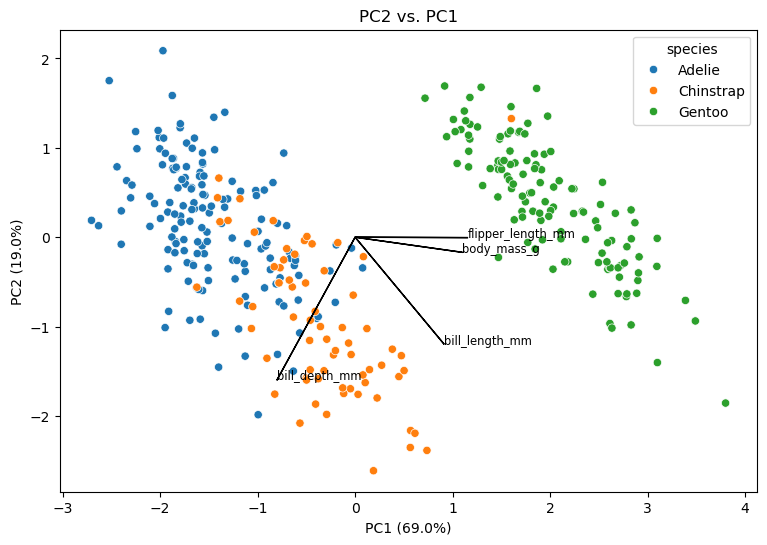

In [31]:
plt.figure(figsize = (9, 6))
plt.title("PC2 vs. PC1")
plt.xlabel(f"PC1 ({np.round(percent_var_explained[0],2)*100}%)")
plt.ylabel(f"PC2 ({np.round(percent_var_explained[1],2)*100}%)")
sns.scatterplot(x = new_penguins["v1"], y = new_penguins["v2"], hue = penguins["species"]);

for i in range(vt.shape[1]):
    plt.arrow(0, 0, vt.iloc[0,i]*2, vt.iloc[1,i]*2, color = "black")
    plt.text(vt.iloc[0,i]*2, vt.iloc[1,i]*2, features_std.columns[i], fontsize = "small")

88% of the variation in the data is being explained by the first two PCs. Will we see much structure in the data if we visualize PC3 and 4?

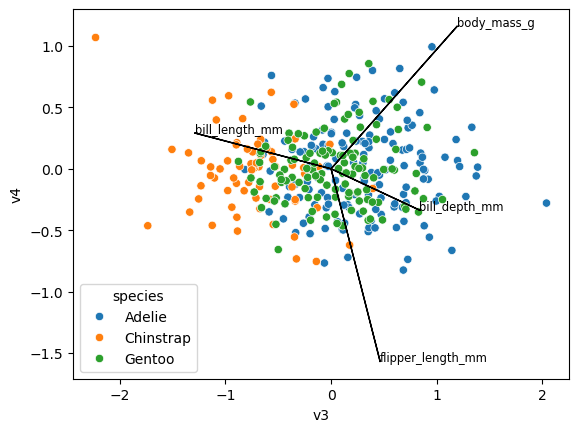

In [34]:
sns.scatterplot(x = new_penguins["v3"], y = new_penguins["v4"], hue = penguins["species"])

for i in range(vt.shape[1]):
    plt.arrow(0, 0, vt.iloc[2,i]*2, vt.iloc[3,i]*2, color = "black")
    plt.text(vt.iloc[2,i]*2, vt.iloc[3,i]*2, features_std.columns[i], fontsize = "small")